## Your Group

Submitted by Group 11:

- Ehsan Attar
- Name2
- Name3
- Name4

By submitting this exercise, you confirm the following:

- **All people** listed above **contributed** to this solution
- **No other people** were **involved** in this solution
- **No contents** of this solution were **copied from others** (this includes people, large language models, websites, etc.)

*Put your input image files in `data/input`.*

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import blob_log, blob_dog, blob_doh, corner_harris, corner_peaks
np.random.seed(42)
H, W = 256, 256 # Image dimensions

## Helper Functions

In [2]:
def read_image(filename, format='gray'):
    """
    Read image from file and convert to specified format.
    """
    basepath = os.path.curdir
    img = cv2.imread(os.path.join(basepath, 'data', 'input', filename))
    if format == 'gray':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    elif format == 'rgb':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    return img.astype(np.float64)

In [3]:
def make_blob_image(
    radii: list = [4, 8, 16, 32, 64],
    size: int = 256,
    overlap: float = 0.0,
) -> tuple:
    """
    Synthetic black image with white filled circles of given radii.
    Circles are placed left-to-right with controlled spacing.

    Parameters
    ----------
    radii   : list of int — radii of circles to draw
    size    : int         — image is (size x size)
    overlap : float       — fraction of the smaller circle's radius
                           by which adjacent circles may overlap.
                           0.0  = circles just touch (default, no overlap)
                           0.5  = circles overlap by 50% of the smaller radius
                           -0.5 = extra gap equal to 50% of the smaller radius

    Returns
    -------
    img     : np.ndarray (size, size, uint8)
    centres : list of (cx, cy) tuples
    """
    img = np.zeros((size, size), dtype=np.uint8)
    centres = []
    cy = size // 2

    # Place first circle: its left edge starts at one radius from the border
    cx = radii[0] + 5

    for i, r in enumerate(radii):
        centres.append((cx, cy))
        cv2.circle(img, (cx, cy), r, 255, -1)

        if i < len(radii) - 1:
            r_next = radii[i + 1]
            gap = overlap * min(r, r_next)
            # next centre = current centre + current radius + next radius - gap
            cx = cx + r + r_next - int(gap)

    return img, centres

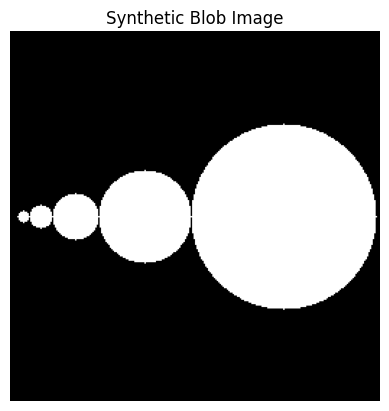

In [4]:
sample_blob_img = make_blob_image(overlap=0.0)
plt.imshow(sample_blob_img[0], cmap='gray'); plt.title('Synthetic Blob Image'); plt.axis('off'); plt.show()

In [5]:
def make_ellipse_image(
    aspect_ratios: list = [2.0, 3.0, 4.0],
    base_radius: int = 40,
    size: int = 256,
    gap_px: int = 5,
    angle: float = 90.0,
) -> tuple:
    """
    Synthetic black image with white filled ellipses of varying aspect ratios.
    Major axis is always base_radius; minor axis = base_radius / aspect_ratio.

    Parameters
    ----------
    aspect_ratios : list of float — major/minor axis ratio.
                    1.0 = circle, 2.0 = twice as wide as tall, etc.
    base_radius   : int   — length of the major axis (semi-axis a) in pixels
    size          : int   — image is (size x size)
    gap_px        : int   — fixed pixel gap between adjacent ellipses
    angle         : float — rotation of all ellipses in degrees (0 = horizontal)

    Returns
    -------
    img     : np.ndarray (size x size, uint8)
    centres : list of (cx, cy) tuples
    axes    : list of (a, b) tuples — (major, minor) semi-axes for each ellipse
    """
    img = np.zeros((size, size), dtype=np.uint8)
    centres = []
    axes_list = []
    cy = size // 2
    cx = base_radius + gap_px   # left margin for first ellipse

    for i, ar in enumerate(aspect_ratios):
        a = base_radius                     # major semi-axis (horizontal)
        b = max(1, int(base_radius / ar))   # minor semi-axis (vertical)

        centres.append((cx, cy))
        axes_list.append((a, b))
        cv2.ellipse(img, (cx, cy), (a, b), angle, 0, 360, 255, -1)

        if i < len(aspect_ratios) - 1:
            # next centre clears current major axis + next major axis + gap
            cx = cx + a + base_radius + gap_px

    return img, centres, axes_list

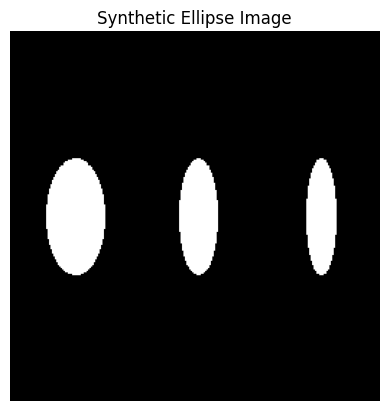

In [6]:
sample_ellipse_img = make_ellipse_image()
plt.imshow(sample_ellipse_img[0], cmap='gray'); plt.title('Synthetic Ellipse Image'); plt.axis('off'); plt.show()

In [7]:
def rotate_image(image: np.ndarray, angle_deg: float) -> np.ndarray:
    """Rotate image about its centre. Empty regions are filled with black."""
    h, w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle_deg, 1.0)
    return cv2.warpAffine(image, M, (w, h))

In [8]:
def plot_1d(signals, labels=None, title=None, xlabel='Pixel', ylabel='Intensity', figsize=(10, 3.5)):
    labels = list(labels or []) + [f"Signal {i+1}" for i in range(len(labels or []), len(signals))]
    fig, ax = plt.subplots(figsize=figsize)
    for signal, label in zip(signals, labels):
        ax.plot(signal, label=label, linewidth=1.5)
    ax.set_title(title or '', fontsize=11, fontweight='bold')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    return fig, ax

## Question 1: Edge Detection

### (1a) Compute and visualise image gradients manually

1. Use `cv2.filter2D()` and the Sobel kernels $S_x \text{ and } S_y$ defined explicitly as NumPy arrays **(do not use `cv2.Sobel()` directly** — define the kernels yourself), and apply both to a greyscale image (any image of your choice).

2. Compute:
* Gradient components $G_x$ and $G_y$ at each pixel
* Gradient magnitude $\mid G \mid$ at each pixel
* Gradient orientation $\theta$ at each pixel

3. Visualise all four outputs. Use cmap='hsv' for the direction map so angular values are visually distinct. 

4. What do you notice about where the magnitude is large vs. where the direction is meaningful?

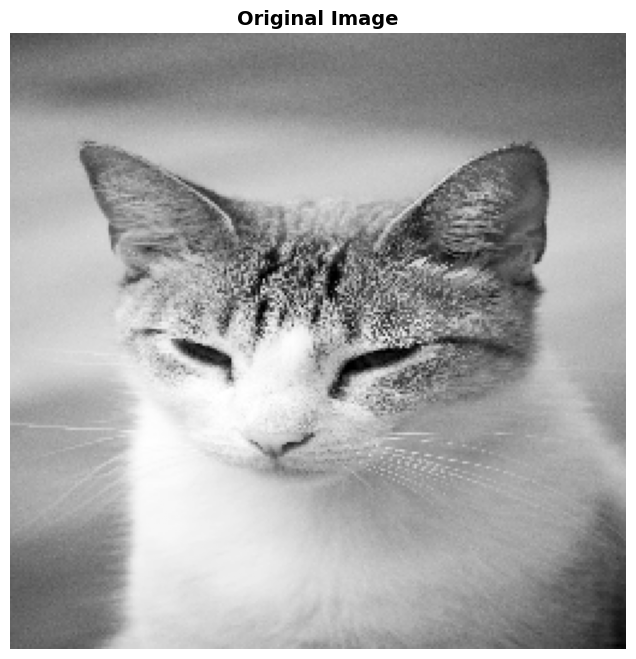

In [9]:
cat = read_image('pexels-andersonrj-5639946.jpg', format='gray')

plt.figure(figsize=(10, 8))
plt.imshow(cat, cmap='gray')
plt.title('Original Image', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

In [10]:
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float64)

sobel_y = np.array([[-1, -2, -1],
                    [0,  0,  0],
                    [1,  2,  1]], dtype=np.float64)

G_x = cv2.filter2D(cat, cv2.CV_64F, sobel_x)
G_y = cv2.filter2D(cat, cv2.CV_64F, sobel_y)

magnitude = np.hypot(G_x, G_y)
orientation = np.arctan2(G_y, G_x)
orientation_degrees = np.degrees(orientation)
magnitude_normalized = (magnitude - magnitude.min()) / (magnitude.max() - magnitude.min())
orientation_normalized = (orientation_degrees + 180) / 360

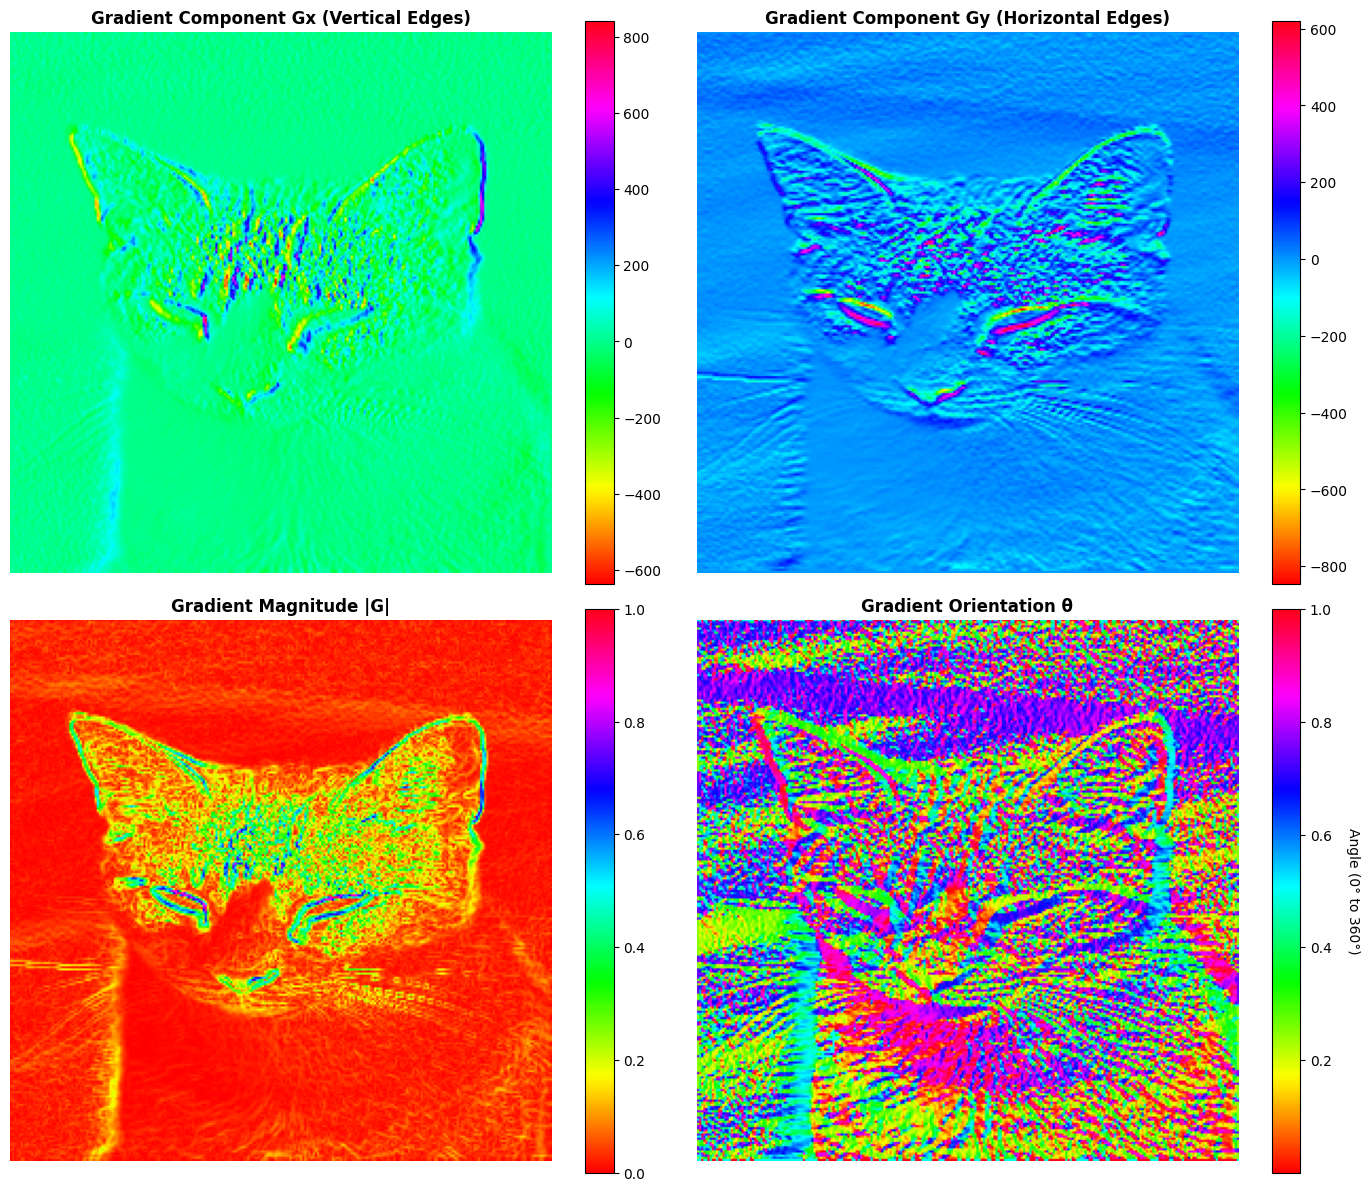

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

ax = axes[0, 0]
img1 = ax.imshow(G_x, cmap='hsv')
ax.set_title('Gradient Component Gx (Vertical Edges)', fontsize=12, fontweight='bold')
ax.axis('off')
plt.colorbar(img1, ax=ax)

ax = axes[0, 1]
img2 = ax.imshow(G_y, cmap='hsv')
ax.set_title('Gradient Component Gy (Horizontal Edges)', fontsize=12, fontweight='bold')
ax.axis('off')
plt.colorbar(img2, ax=ax)

ax = axes[1, 0]
img3 = ax.imshow(magnitude_normalized, cmap='hsv')
ax.set_title('Gradient Magnitude |G|', fontsize=12, fontweight='bold')
ax.axis('off')
plt.colorbar(img3, ax=ax)

ax = axes[1, 1]
img4 = ax.imshow(orientation_normalized, cmap='hsv')
ax.set_title('Gradient Orientation θ', fontsize=12, fontweight='bold')
ax.axis('off')
cbar = plt.colorbar(img4, ax=ax)
cbar.set_label('Angle (0° to 360°)', rotation=270, labelpad=20)

plt.tight_layout()
plt.savefig('data/output/cat_gradient_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Magnitude is Large at:

* Object boundaries (face outline, ears, whiskers)
* High-contrast features (eyes, nose, mouth)
* Corners and structural edges

Direction is Meaningful at:

* Exactly where magnitude is large (strong edges)
* Shows organized, consistent color patterns
* Indicates perpendicular orientation of edges

### (1b) Noise sensitivity of Derivatives

1. Derivatives amplify noise. Verify this by:

* Adding Gaussian noise $(\sigma_{noise}=15)$ to your image
* Computing gradient magnitude on the noisy image without any pre-smoothing
* Computing gradient magnitude *with* Gaussian pre-smoothing at three different scales

2. Plot the gradient magnitude cross-section through a known edge for all four cases using `plot_1d()`. 

3. How does increasing $\sigma$ affect: (a) the noise in the gradient, and (b) the sharpness and position of the edge response? What is the fundamental trade-off being made here?


### (1c) Comparing Sobel, LoG, and Canny on noisy images

1. On the previously corrupted image apply three edge detectors:

* Sobel (with Gaussian smoothing)
* Laplacian of Gaussian (LoG)- apply `cv2.Laplacian()` after Gaussian smoothing, then threshold zero-crossings
* Canny (experiment with the sigmas and thresholds to get the best results on your image)

2. Visualise the results. Which produces the cleanest, thinnest edges? Which is most sensitive to noise? Discuss why LoG produces double edges at boundaries while Canny does not.

## Blob Detection

### (2a) LoG Response

Generate a synthetic image, containing a single row of circle of radius $r \in \{4, 8, 16, 32, 64\}$ on a black background (use the provided method ``make_blob_image()``). 

For each image, compute the LoG response at the circle's centre across $\sigma \in [1, 50]$ sampled at 30 points (use ``blob_log()``) and find the $\sigma$ for each detected blob. Plot the response of the cross-section line along the blob centers for each of the 5 detected scales on the same axes using ``plot_1d()``.

### (2b) Relation between $r$ and $\sigma_{peak}$

Plot $r \text{ vs. } \sigma_{peak}$ and fit a line through the origin. What is the slope? The theory predicts $r = \sqrt{2}\,\sigma_{peak}$.

### (2c) Response to Elliptical Blobs

Now test with non-circular blobs: generate ellipses of varying aspect ratios:  $\{1:1,\ 2:1,\ 3:1\}$ using ``make_ellipse_image()``. What $\sigma$ does ``blob_log()`` report for an ellipse? Using $r = \sqrt{2}\,\sigma_{peak}$ is $r$ closer to its major axis length, minor axis length, or their geometric mean? Run the experiment and compare for the diff aspect ratios.

### (2d) Response to Overlapping Blobs

Run ``blob_log()`` on three blob images with varying overlap (generate with `make_blob_image()`) at two overlap tolerance levels: overlap=0.0 (no overlapping blobs allowed) and overlap=0.8 (blobs may overlap significantly). Visualise both. How many blobs does each setting return? When would you want a high overlap tolerance in practice?

### (2e) LoG vs DoH

The `blob_doh()` detector does not use scale-normalised responses- it uses the determinant of the Hessian matrix directly. This makes it very fast but changes its behaviour. Run `blob_doh()` and `blob_log()` on the same natural image (any image of your choice) and compare: which finds larger blobs more reliably? Which is better for small blobs?

## Corner Detection

### (3a) The Harris response map R

Compute the Harris corner response using `corner_harris()` on a grayscale image (any image of your choice). Visualise the full raw $R$ map. From the lecture, $R$ has three regimes.

Identify one example of each regime in your image. Crop and show those three patches side by side with their mean $R$ values as titles.

### (3b) Extracting corners — threshold and spatial suppression

Use `corner_peaks()` to extract corner coordinates from the Harris $R$ map. Sweep two parameters independently:

* `threshold_rel` $\in \{0.001, 0.01, 0.05, 0.1 \}$ (with fixed min_distance=7)
* `min_distance` $\in \{3, 7, 15, 30 \}$ (with fixed threshold_rel=0.02)

For each sweep, draw detected point on the image and show the results. Plot corner count vs each parameter using `plot_1d()`. What is min_distance doing geometrically?

### (3c) Harris is rotation-invariant

Rotate your image by $\{30°, 60°, 90°\}$ using the provided ``rotate_image()`` helper. Run ``corner_harris()`` + ``corner_peaks()`` (with fixed parameters) on the original and all three rotated versions. Report the corner count for each and visualise detections.

Does the count stay roughly constant across rotations? Explain from the definition $R = \det(H) - k(\text{trace}\,H)^2$ why rotation does not change $R$. 

### (3d) Effect of Scale

Resize your image to scales \{0.5\times, 0.75\times, 1.0\times, 1.5\times\} using ``cv2.resize()``. Run ``corner_harris()`` + ``corner_peaks()`` with the same fixed parameters on each. Report and plot corner counts vs scale. Then on the $0.5\times$ image, double the sigma parameter of corner_harris to compensate- what happens to the count? 

Why does Harris fail under scale change despite being rotation-invariant, and what would be needed to make it truly scale-invariant?

### (3e) Harris vs Shi-Tomasi

Compute both response maps on the same image:

* Harris: ``corner_harris()`` (uses $R = \det(H) - k(\text{trace}\,H)^2$ )
* Shi-Tomasi: ``corner_shi_tomasi()`` (uses $R = \min(\lambda_1, \lambda_2)$)

Visualise both response maps side by side. Extract corners from each with ``corner_peaks()`` using the same ``threshold_rel`` and ``min_distance``, draw them, and report the counts. Do the two methods detect corners at the same locations even though the scores differ?

Is there a scenario where Harris would detect a corner that Shi-Tomasi misses, or vice versa?